### ListOps with LMU


In [2]:
from __future__ import annotations
from typing import Dict, Any

import torch
import os
from pathlib import Path

from listops_task import ListOpsTask
from src.train_utils.trainer import Trainer

### Configuration

We define hyperparameters and configurations for the training process.
This includes data paths, batch sizes, learning rates, and model-specific parameters.
Using unified block factory from src.utils.block_factory for consistent configuration.

In [3]:
from src.utils.block_factory import make_lmu_block_cfg_ctor

In [4]:
current_dir = Path.cwd()
project_root = current_dir.parent.parent.parent
data_root = str(project_root / "src" / "datasets" / "LRA" / "listOps")

args: Dict[str, Any] = {
    "data_root": data_root,
    "batch": 128,
    "data_loader_kwargs": {
        "num_workers": 0,
        "max_length": 512, #2000,
        "pin_memory": False,
        "persistent_workers": False,
    },

    "epochs": 50,
    "lr": 1e-3,
    "wd": 1e-4,
    "amp": False,
    "save_dir": "./runs/listops_lmu_task",
    "warmup_epochs": 5,
    "patience": 5,
    "min_delta": 0.001,
    "early_key": "accuracy",

    "d_model": 128,
    "depth": 4,
    "dropout": 0.1,
    "mlp_ratio": 2.0,
    "droppath_final": 0.0,
    "layerscale_init": 0.0,
    "residual_gain": 1.0,
    "pool": "mean",

    "max_length": 2000,
}

args["block_cfg_ctor"] = make_lmu_block_cfg_ctor(
    dropout=args["dropout"],
    mlp_ratio=args["mlp_ratio"],
    droppath_final=args["droppath_final"],
    layerscale_init=args["layerscale_init"],
    residual_gain=args["residual_gain"],
    pool=args["pool"],
)

if torch.backends.mps.is_available():
    args["device"] = torch.device("mps")
    print("Using MPS")
elif torch.cuda.is_available():
    args["device"] = torch.device("cuda")
    print("Using CUDA")
else:
    args["device"] = torch.device("cpu")
    args["amp"] = False
    print("Using CPU")

Using MPS


### Training

With the configuration set up, we instantiate the `ListOpsTask` and the `Trainer`.
The `fit` method on the trainer will start the training process, which includes training,
validation, and saving the best model based on the validation accuracy.

In [5]:
from src.utils.visualization import plot_classification_history as plot_history

In [6]:
task = ListOpsTask()

if torch.backends.mps.is_available():
    torch.mps.set_per_process_memory_fraction(0.9)
    os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

trainer = Trainer(args=args, task=task)

best_metric, ckpt_path = trainer.fit()
print(f"Done. Best {trainer.early_key}={best_metric:.4f} @ {ckpt_path}")

ListOps Loaders Created:
  Train: 96000 samples, 750 batches
  Val:   2000 samples, 16 batches
  Test:  2000 samples, 16 batches
  Max length: 512
  Vocab size: 25
  Classes: 10 (0-9)
Using embedding layer with vocab_size=25


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: divide by zero encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: overflow encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: invalid value encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:358: RuntimeWarning: divide by zero encountered in matmul
  eAw = eAw @ eAw
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:358: RuntimeWarning: overflow encountered in matmul
  eAw = eAw @ eAw
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/li

💾 saved best model to ./runs/listops_lmu_task/best.pt
✅ new best acc 0.0970
Epoch 000/50 | train 2.3728/0.0896 | val 2.3616/0.0970 | t 460.8s/3.8s | lr 1.00e-06


💾 saved best model to ./runs/listops_lmu_task/best.pt
✅ new best acc 0.1615
Epoch 001/50 | train 2.2516/0.1767 | val 2.2536/0.1615 | t 506.3s/3.6s | lr 2.01e-04


💾 saved best model to ./runs/listops_lmu_task/best.pt
✅ new best acc 0.2545
Epoch 002/50 | train 2.2094/0.2263 | val 2.1542/0.2545 | t 528.1s/4.1s | lr 4.01e-04


...

Epoch 013/50 | train 1.5808/0.3784 | val 1.5845/0.3595 | t 476.5s/3.4s | lr 9.24e-04


Epoch 014/50 | train 1.5716/0.3833 | val 1.5868/0.3535 | t 483.0s/3.4s | lr 9.05e-04


Epoch 015/50 | train 1.5643/0.3833 | val 1.5801/0.3710 | t 484.2s/3.3s | lr 8.83e-04


Epoch 016/50 | train 1.5588/0.3872 | val 1.5753/0.3705 | t 462.9s/3.3s | lr 8.60e-04


⏹ Early stopping (patience=5, best=0.3795).
📊 Training history saved to ./runs/listops_lmu_task/history.json
Done. Best acc=0.3795 @ ./runs/listops_lmu_task/best.pt


### Visualization

Load the best checkpoint and visualize the training history.

ListOps Loaders Created:
  Train: 96000 samples, 750 batches
  Val:   2000 samples, 16 batches
  Test:  2000 samples, 16 batches
  Max length: 512
  Vocab size: 25
  Classes: 10 (0-9)
Using embedding layer with vocab_size=25
Loaded checkpoint from epoch 11
Val metrics: {'loss': 1.585474684715271, 'time_s': 3.3044979579999563, 'acc': 0.37950000023841857}


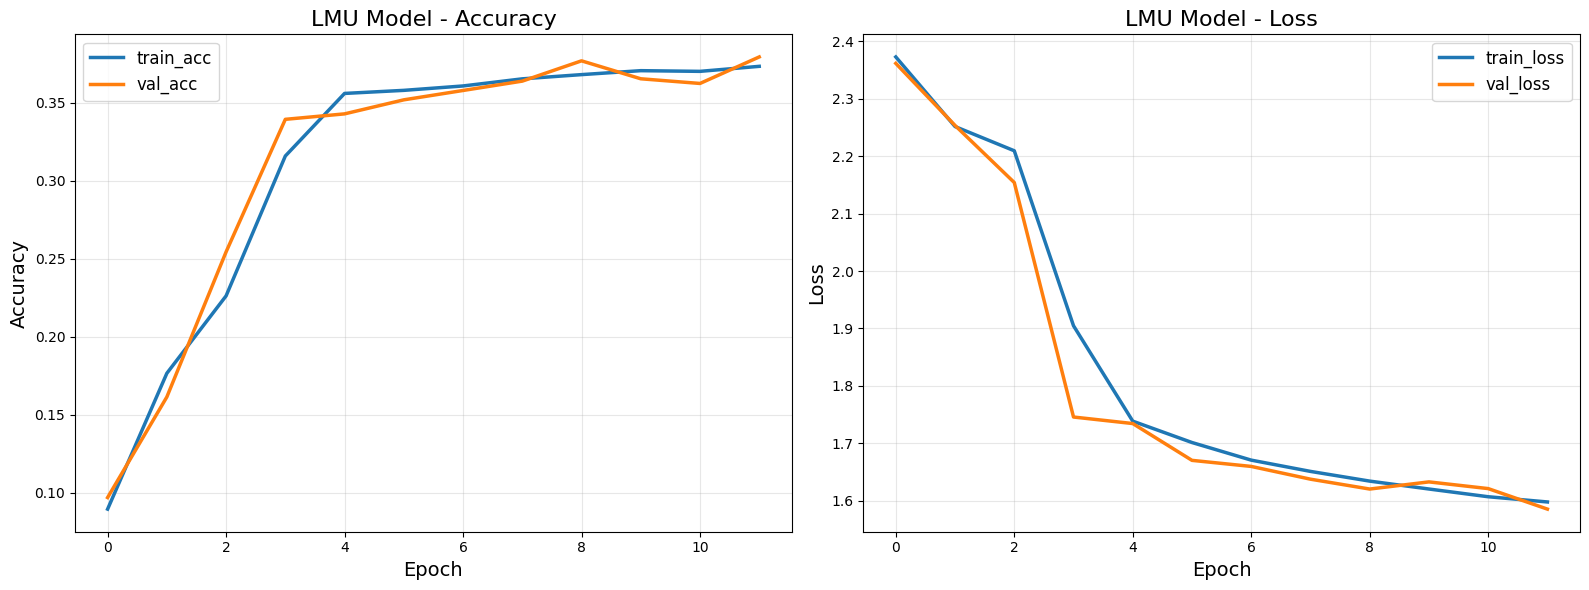

In [7]:
from src.utils.checkpoint import load_trainer_from_checkpoint

trainer = load_trainer_from_checkpoint(
    checkpoint_path=args["save_dir"] + "/best.pt",
    args=args,
    task=ListOpsTask(),
)

history = trainer.history

plot_history(history, model_name="LMU")

### Evaluation

After training, we can evaluate the best model on the test set.
We load the best model from the checkpoint and then run the evaluation.
The results, including accuracy, are printed.

ListOps Loaders Created:
  Train: 96000 samples, 750 batches
  Val:   2000 samples, 16 batches
  Test:  2000 samples, 16 batches
  Max length: 512
  Vocab size: 25
  Classes: 10 (0-9)
Using embedding layer with vocab_size=25
Loaded checkpoint from epoch 11
Val metrics: {'loss': 1.585474684715271, 'time_s': 3.3044979579999563, 'acc': 0.37950000023841857}
ListOps Loaders Created:
  Train: 96000 samples, 750 batches
  Val:   2000 samples, 16 batches
  Test:  2000 samples, 16 batches
  Max length: 512
  Vocab size: 25
  Classes: 10 (0-9)

✅ Test results saved to: runs/listops_lmu_task/test_results.json

   Test Accuracy: 0.3880 (38.80%)
   Test Loss: 1.5839

TEST SET RESULTS
Overall accuracy: 0.3880
Num classes: 10

Top-10 and Bottom-10 Classes by Performance:
Top per-class accuracies:
01. class_0                   : 0.919
02. class_9                   : 0.843
03. class_4                   : 0.223
04. class_5                   : 0.198
05. class_3                   : 0.156
06. class_6      

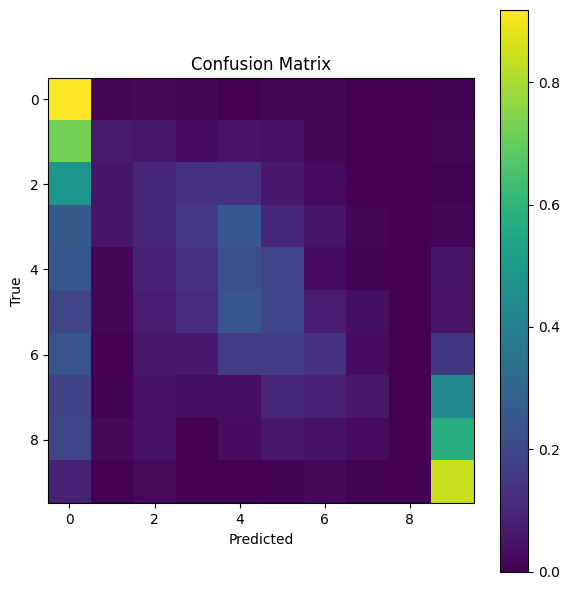

In [8]:
from src.eval.eval_utils import evaluate_classification_model as evaluate_best_model

logits_test, labels_test = evaluate_best_model(
    args=args,
    task=ListOpsTask(),
    best_model_path=f"{args['save_dir']}/best.pt",
    num_classes=10,
    use_test_set=True,
)

### Training with Different Dataset Fractions

This cell demonstrates training with different fractions of the training data
to see how model performance scales with dataset size.


Training with fraction: 0.1
ListOps Loaders Created:
  Train: 96000 samples, 750 batches
  Val:   2000 samples, 16 batches
  Test:  2000 samples, 16 batches
  Max length: 512
  Vocab size: 25
  Classes: 10 (0-9)
   Applying data fraction: 10.0%
   Original train size: 96000
   Original val size: 2000
   Reduced train size: 9596
   Reduced val size: 2000
   Test size: 2000 (unchanged)
Using embedding layer with vocab_size=25


💾 saved best model to ./runs/listops_lmu_task_frac_10/best.pt
✅ new best acc 0.1715
Epoch 000/50 | train 2.2789/0.1708 | val 2.2861/0.1715 | t 52.5s/3.5s | lr 1.00e-06


Epoch 001/50 | train 2.2547/0.1675 | val 2.2565/0.1725 | t 44.7s/3.2s | lr 2.01e-04


💾 saved best model to ./runs/listops_lmu_task_frac_10/best.pt
✅ new best acc 0.1860
Epoch 002/50 | train 2.2490/0.1685 | val 2.2557/0.1860 | t 44.6s/3.2s | lr 4.01e-04


Epoch 003/50 | train 2.2495/0.1763 | val 2.2566/0.1715 | t 44.5s/3.2s | lr 6.00e-04


...

Epoch 022/50 | train 1.6728/0.3767 | val 1.7133/0.3595 | t 46.7s/3.3s | lr 6.87e-04


Epoch 023/50 | train 1.6588/0.3841 | val 1.7824/0.3400 | t 46.9s/3.4s | lr 6.55e-04


Epoch 024/50 | train 1.6557/0.3818 | val 1.7064/0.3535 | t 47.0s/3.4s | lr 6.21e-04


Epoch 025/50 | train 1.6387/0.3828 | val 1.7188/0.3600 | t 47.5s/3.4s | lr 5.87e-04


⏹ Early stopping (patience=5, best=0.3610).
📊 Training history saved to ./runs/listops_lmu_task_frac_10/history.json

Training complete for fraction 0.1! Best validation acc: 0.3610
Best model saved to: ./runs/listops_lmu_task_frac_10/best.pt


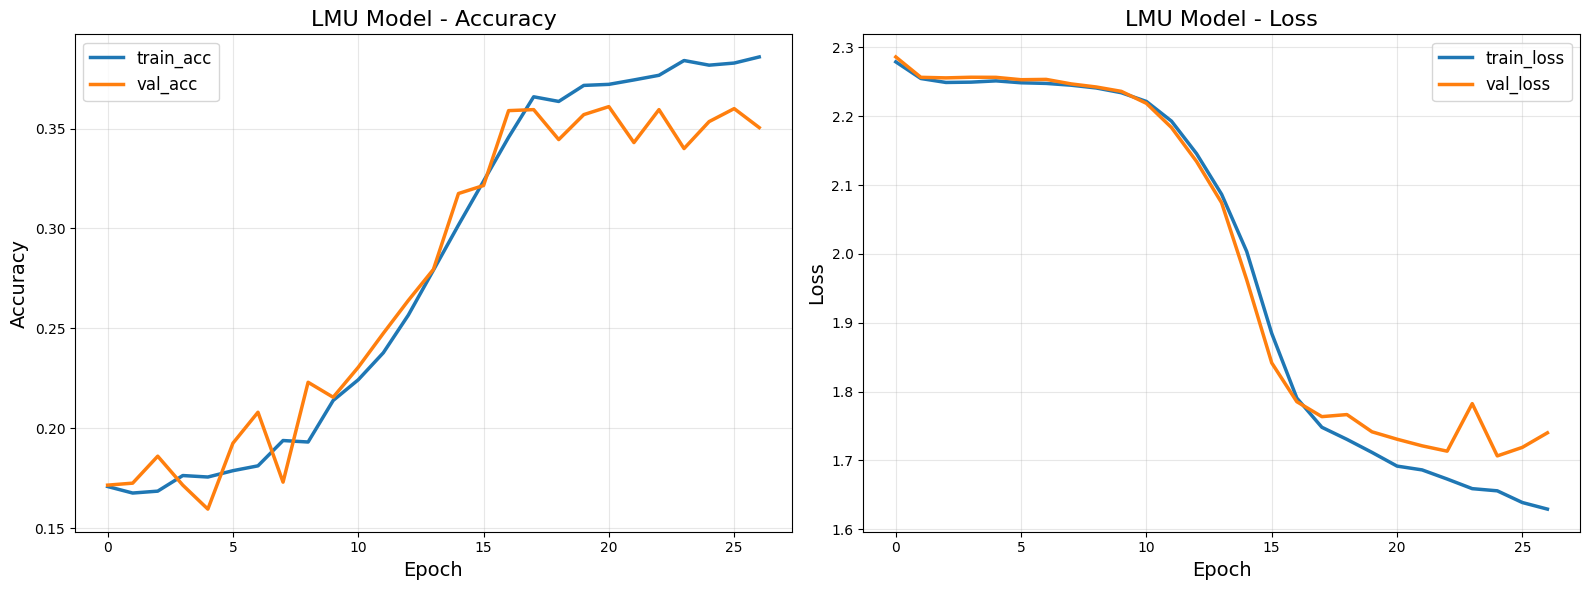

ListOps Loaders Created:
  Train: 96000 samples, 750 batches
  Val:   2000 samples, 16 batches
  Test:  2000 samples, 16 batches
  Max length: 512
  Vocab size: 25
  Classes: 10 (0-9)
   Applying data fraction: 10.0%
   Original train size: 96000
   Original val size: 2000
   Reduced train size: 9596
   Reduced val size: 2000
   Test size: 2000 (unchanged)
Using embedding layer with vocab_size=25
Loaded checkpoint from epoch 20
Val metrics: {'loss': 1.730682686805725, 'time_s': 3.3040116669981217, 'acc': 0.3609999997615814}
ListOps Loaders Created:
  Train: 96000 samples, 750 batches
  Val:   2000 samples, 16 batches
  Test:  2000 samples, 16 batches
  Max length: 512
  Vocab size: 25
  Classes: 10 (0-9)

✅ Test results saved to: runs/listops_lmu_task_frac_10/test_results.json

   Test Accuracy: 0.3700 (37.00%)
   Test Loss: 1.6975

TEST SET RESULTS
Overall accuracy: 0.3700
Num classes: 10

Top-10 and Bottom-10 Classes by Performance:
Top per-class accuracies:
01. class_9              

💾 saved best model to ./runs/listops_lmu_task_frac_25/best.pt
✅ new best acc 0.1690
Epoch 000/50 | train 2.2872/0.1574 | val 2.2933/0.1690 | t 113.9s/3.3s | lr 1.00e-06


💾 saved best model to ./runs/listops_lmu_task_frac_25/best.pt
✅ new best acc 0.1720
Epoch 001/50 | train 2.2524/0.1692 | val 2.2543/0.1720 | t 124.2s/3.4s | lr 2.01e-04


Epoch 002/50 | train 2.2498/0.1723 | val 2.2545/0.1730 | t 123.7s/3.4s | lr 4.01e-04


Epoch 003/50 | train 2.2490/0.1766 | val 2.2608/0.1595 | t 123.8s/3.4s | lr 6.00e-04


...

Epoch 021/50 | train 1.5830/0.3936 | val 1.6675/0.3475 | t 126.2s/3.5s | lr 7.19e-04


Epoch 022/50 | train 1.5750/0.3951 | val 1.6714/0.3540 | t 126.0s/3.5s | lr 6.87e-04


Epoch 023/50 | train 1.5620/0.3977 | val 1.6738/0.3590 | t 125.7s/3.5s | lr 6.55e-04


Epoch 024/50 | train 1.5493/0.4024 | val 1.6903/0.3545 | t 126.1s/3.5s | lr 6.21e-04


⏹ Early stopping (patience=5, best=0.3695).
📊 Training history saved to ./runs/listops_lmu_task_frac_25/history.json

Training complete for fraction 0.25! Best validation acc: 0.3695
Best model saved to: ./runs/listops_lmu_task_frac_25/best.pt


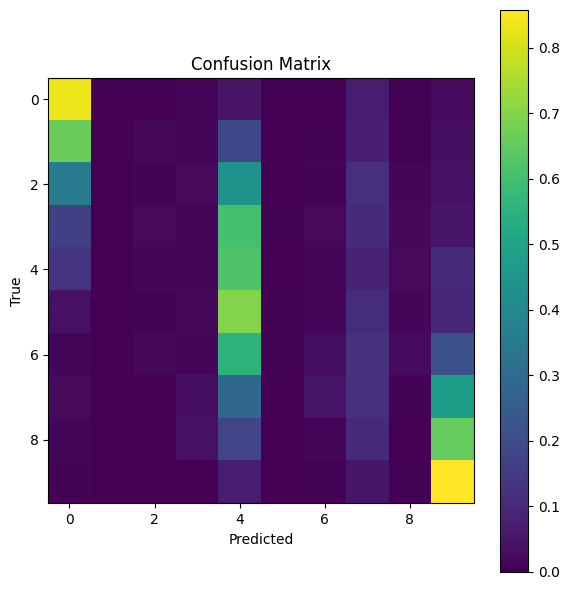

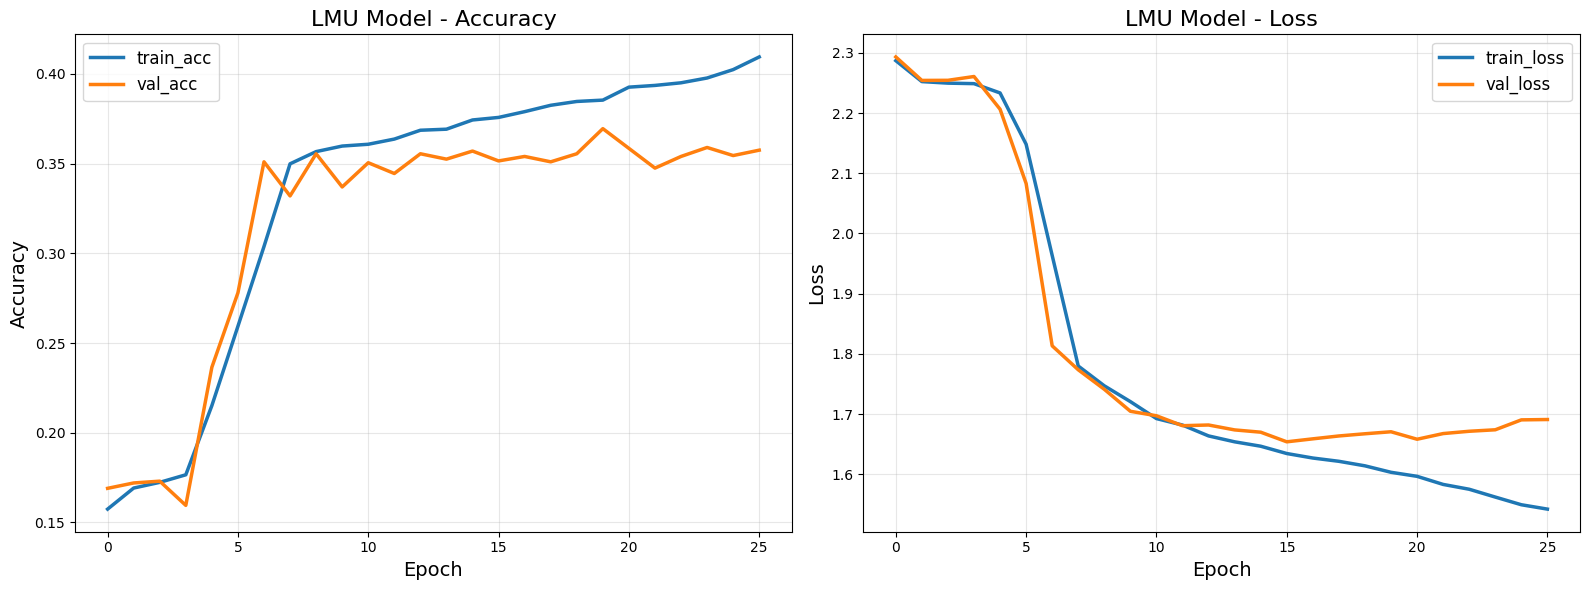

ListOps Loaders Created:
  Train: 96000 samples, 750 batches
  Val:   2000 samples, 16 batches
  Test:  2000 samples, 16 batches
  Max length: 512
  Vocab size: 25
  Classes: 10 (0-9)
   Applying data fraction: 25.0%
   Original train size: 96000
   Original val size: 2000
   Reduced train size: 23997
   Reduced val size: 2000
   Test size: 2000 (unchanged)
Using embedding layer with vocab_size=25
Loaded checkpoint from epoch 19
Val metrics: {'loss': 1.6705248403549193, 'time_s': 3.569985292000638, 'acc': 0.3695000004768372}
ListOps Loaders Created:
  Train: 96000 samples, 750 batches
  Val:   2000 samples, 16 batches
  Test:  2000 samples, 16 batches
  Max length: 512
  Vocab size: 25
  Classes: 10 (0-9)

✅ Test results saved to: runs/listops_lmu_task_frac_25/test_results.json

   Test Accuracy: 0.3750 (37.50%)
   Test Loss: 1.6588

TEST SET RESULTS
Overall accuracy: 0.3750
Num classes: 10

Top-10 and Bottom-10 Classes by Performance:
Top per-class accuracies:
01. class_9             

💾 saved best model to ./runs/listops_lmu_task_frac_50/best.pt
✅ new best acc 0.0840
Epoch 000/50 | train 2.3589/0.0884 | val 2.3645/0.0840 | t 248.6s/3.6s | lr 1.00e-06


💾 saved best model to ./runs/listops_lmu_task_frac_50/best.pt
✅ new best acc 0.1600
Epoch 001/50 | train 2.2545/0.1688 | val 2.2553/0.1600 | t 255.7s/3.6s | lr 2.01e-04


💾 saved best model to ./runs/listops_lmu_task_frac_50/best.pt
✅ new best acc 0.2215
Epoch 002/50 | train 2.2482/0.1786 | val 2.2495/0.2215 | t 252.9s/3.5s | lr 4.01e-04


💾 saved best model to ./runs/listops_lmu_task_frac_50/best.pt
✅ new best acc 0.2600
Epoch 003/50 | train 2.2036/0.2351 | val 2.1434/0.2600 | t 254.8s/3.5s | lr 6.00e-04


...

Epoch 014/50 | train 1.5927/0.3764 | val 1.6251/0.3640 | t 255.7s/3.6s | lr 9.05e-04


Epoch 015/50 | train 1.5849/0.3782 | val 1.6297/0.3570 | t 255.8s/3.6s | lr 8.83e-04


Epoch 016/50 | train 1.5773/0.3822 | val 1.6187/0.3605 | t 257.4s/3.6s | lr 8.60e-04


Epoch 017/50 | train 1.5697/0.3861 | val 1.6338/0.3695 | t 257.7s/3.6s | lr 8.35e-04


⏹ Early stopping (patience=5, best=0.3715).
📊 Training history saved to ./runs/listops_lmu_task_frac_50/history.json

Training complete for fraction 0.5! Best validation acc: 0.3715
Best model saved to: ./runs/listops_lmu_task_frac_50/best.pt


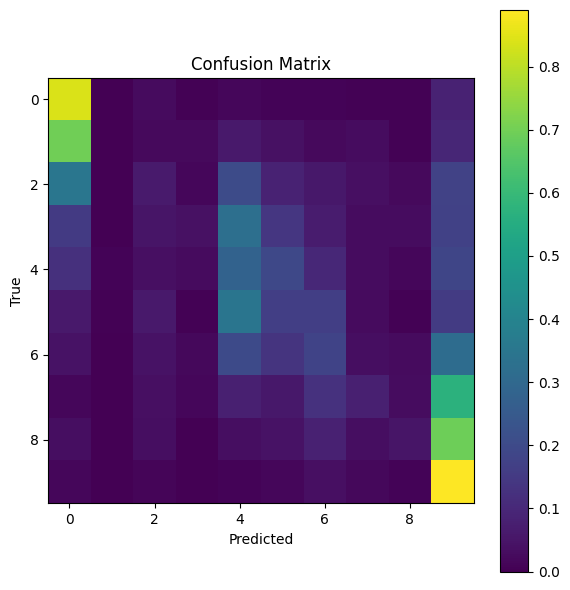

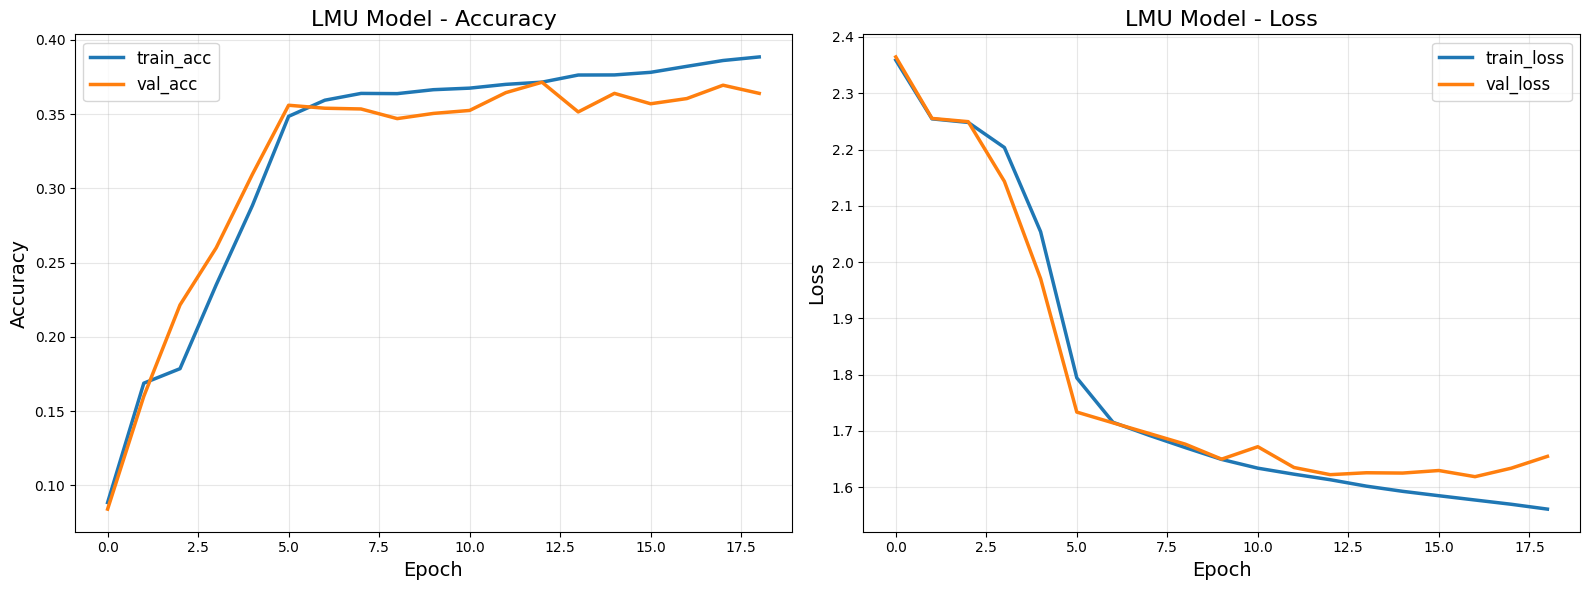

ListOps Loaders Created:
  Train: 96000 samples, 750 batches
  Val:   2000 samples, 16 batches
  Test:  2000 samples, 16 batches
  Max length: 512
  Vocab size: 25
  Classes: 10 (0-9)
   Applying data fraction: 50.0%
   Original train size: 96000
   Original val size: 2000
   Reduced train size: 47997
   Reduced val size: 2000
   Test size: 2000 (unchanged)
Using embedding layer with vocab_size=25
Loaded checkpoint from epoch 12
Val metrics: {'loss': 1.6223159160614014, 'time_s': 3.5740192090015626, 'acc': 0.3715000004768372}
ListOps Loaders Created:
  Train: 96000 samples, 750 batches
  Val:   2000 samples, 16 batches
  Test:  2000 samples, 16 batches
  Max length: 512
  Vocab size: 25
  Classes: 10 (0-9)

✅ Test results saved to: runs/listops_lmu_task_frac_50/test_results.json

   Test Accuracy: 0.3820 (38.20%)
   Test Loss: 1.6038

TEST SET RESULTS
Overall accuracy: 0.3820
Num classes: 10

Top-10 and Bottom-10 Classes by Performance:
Top per-class accuracies:
01. class_9            

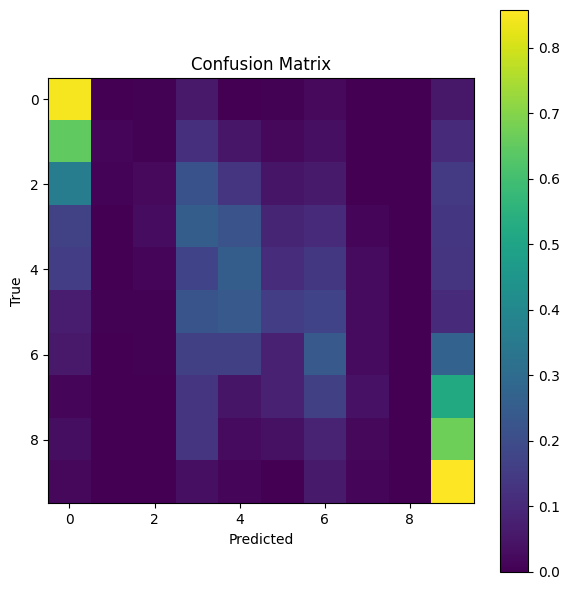

In [9]:
from src.eval.eval_utils import evaluate_classification_model as evaluate_best_model

if torch.backends.mps.is_available():
    torch.mps.set_per_process_memory_fraction(0.9)
    os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

for frac in [0.1, 0.25, 0.5]:
    print(f"\nTraining with fraction: {frac}")

    args["fraction"] = frac
    args["save_dir"] = f"./runs/listops_lmu_task_frac_{int(frac*100)}"
    trainer = Trainer(args=args, task=ListOpsTask())
    best_metric, best_path = trainer.fit()

    print(f"\nTraining complete for fraction {frac}! Best validation {trainer.early_key}: {best_metric:.4f}")
    print(f"Best model saved to: {best_path}")

    history = trainer.history
    plot_history(history, model_name="LMU")

    logits_test, labels_test = evaluate_best_model(
        args=args,
        task=ListOpsTask(),
        best_model_path=best_path,
        num_classes=10,
        use_test_set=True,
    )